In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1]:
df = pd.read_csv(r"C:\Users\HP\Desktop\ecommerce_cleaned.csv")

print("Dataset loaded successfully!")

NameError: name 'pd' is not defined

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\HP\Desktop\ecommerce_week1_raw.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,Order ID,Customer ID,Product Name,Category,Quantity,Unit Price,Total Amount,Order Date,Payment Mode,Delivery Status,City
0,ORD00001,CUST0088,Perfume,Beauty,3,2319,6957,2025-08-03,Net Banking,Delivered,Bengaluru
1,ORD00002,CUST0022,Storage Box,Home & Kitchen,2,2683,5366,2025-11-10,Net Banking,Delivered,Pune
2,ORD00003,CUST0051,Bedsheet,Home & Kitchen,2,1225,2450,2025-06-24,Cash on Delivery,Delivered,Delhi
3,ORD00004,CUST0014,Storage Box,Home & Kitchen,3,3138,9414,2025-03-30,Credit Card,Delivered,Chennai
4,ORD00005,CUST0206,Cricket Bat,Sports,4,4314,17256,2025-02-04,UPI,Delivered,Bengaluru


In [5]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 8


In [6]:
# Show duplicate rows

df[df.duplicated()]

,Order ID,Customer ID,Product Name,Category,Quantity,Unit Price,Total Amount,Order Date,Payment Mode,Delivery Status,City
1000,ORD00842,CUST0217,Wireless Headphones,Electronics,1,5993,5993,2025-11-24,Debit Card,Delivered,Delhi
1001,ORD00957,CUST0113,Sneakers,Fashion,3,2827,8481,2025-03-13,Debit Card,Delivered,Aurangabad
1002,ORD00545,CUST0177,Cricket Bat,Sports,2,348,696,2025-11-22,Debit Card,Delivered,Chennai
1003,ORD00174,CUST0133,Running Shoes,Sports,1,3011,3011,2025-01-17,Cash on Delivery,Shipped,Chennai
1004,ORD00760,CUST0055,Football,Sports,4,733,2932,2025-10-15,Debit Card,Delivered,Hyderabad
1006,ORD00122,CUST0102,Cricket Bat,Sports,2,1028,2056,2025-10-16,UPI,Delivered,Latur
1007,ORD00231,CUST0048,Water Bottle,Home & Kitchen,4,3384,13536,2025-03-16,Credit Card,Delivered,Latur
1009,ORD00121,CUST0072,Power Bank,Electronics,4,2263,9052,2025-12-10,Debit Card,Cancelled,Pune


In [7]:
# Remove duplicate rows

df_clean = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Rows after removing duplicates:", len(df_clean))
print("Duplicates removed:", len(df) - len(df_clean))

Original rows: 1010
Rows after removing duplicates: 1002
Duplicates removed: 8


In [8]:
print("Remaining duplicate rows:", df_clean.duplicated().sum())

Remaining duplicate rows: 0


In [9]:
# Check invalid Quantity values

print("Negative Quantity:")
print(df_clean[df_clean["Quantity"] < 0])

print("\nZero Quantity:")
print(df_clean[df_clean["Quantity"] == 0])

Negative Quantity:
     Order ID Customer ID   Product Name        Category  Quantity  \
11   ORD00012    CUST0284       Football          Sports        -3   
176  ORD00177    CUST0181        Handbag         Fashion        -4   
509  ORD00510    CUST0232      Face Wash          Beauty        -3   
811  ORD00812    CUST0140         Jacket         Fashion        -2   
844  ORD00845    CUST0107  Mixer Grinder  Home & Kitchen        -5   

     Unit Price  Total Amount  Order Date      Payment Mode Delivery Status  \
11         3360         10080  2025-05-14  Cash on Delivery       Delivered   
176        2182          8728  2025-09-26  Cash on Delivery       Delivered   
509        2412          7236  2025-02-18        Debit Card       Delivered   
811         391           782  2025-09-09       Credit Card       Delivered   
844        5497         27485  2025-10-18        Debit Card       Cancelled   

          City  
11      Nagpur  
176    Chennai  
509  Hyderabad  
811  Bengaluru  


In [10]:
# Remove negative quantity records

df_clean = df_clean[df_clean["Quantity"] > 0].copy()

print("Rows after removing invalid Quantity:", len(df_clean))
print("Negative Quantity remaining:", (df_clean["Quantity"] < 0).sum())

Rows after removing invalid Quantity: 997
Negative Quantity remaining: 0


In [11]:
# Verify Quantity values

print("Minimum Quantity:", df_clean["Quantity"].min())
print("Maximum Quantity:", df_clean["Quantity"].max())

Minimum Quantity: 1
Maximum Quantity: 5


In [12]:
# Check invalid Unit Price values

print("Zero Unit Price:")
print(df_clean[df_clean["Unit Price"] == 0])

print("\nNegative Unit Price:")
print(df_clean[df_clean["Unit Price"] < 0])

Zero Unit Price:
     Order ID Customer ID Product Name     Category  Quantity  Unit Price  \
190  ORD00191    CUST0231    USB Cable  Electronics         2           0   
225  ORD00226    CUST0243    Face Wash       Beauty         4           0   
260  ORD00261    CUST0024     Sneakers      Fashion         1           0   
524  ORD00525    CUST0072  Moisturizer       Beauty         3           0   
804  ORD00805    CUST0086  Cricket Bat       Sports         5           0   

     Total Amount  Order Date Payment Mode Delivery Status       City  
190          2406  2025-05-06  Credit Card      Processing  Bengaluru  
225          4340  2025-11-28          UPI       Cancelled      Delhi  
260          2458  2025-07-01  Net Banking       Delivered        NaN  
524          6354  2025-03-23  Credit Card       Delivered     Mumbai  
804          1790  2025-09-08   Debit Card       Delivered  Bengaluru  

Negative Unit Price:
Empty DataFrame
Columns: [Order ID, Customer ID, Product Name, Cat

In [13]:
# Remove records with invalid Unit Price

df_clean = df_clean[df_clean["Unit Price"] > 0].copy()

print("Rows after removing invalid Unit Price:", len(df_clean))
print("Zero Unit Price remaining:", (df_clean["Unit Price"] == 0).sum())
print("Negative Unit Price remaining:", (df_clean["Unit Price"] < 0).sum())

Rows after removing invalid Unit Price: 992
Zero Unit Price remaining: 0
Negative Unit Price remaining: 0


In [14]:
print("Minimum Unit Price:", df_clean["Unit Price"].min())
print("Maximum Unit Price:", df_clean["Unit Price"].max())

Minimum Unit Price: 156
Maximum Unit Price: 7952


In [15]:
# Validate Total Amount

df_clean["Calculated Amount"] = (
    df_clean["Quantity"] * df_clean["Unit Price"]
)

invalid_amount = df_clean[
    df_clean["Total Amount"] != df_clean["Calculated Amount"]
]

print("Incorrect Total Amount records:", len(invalid_amount))

Incorrect Total Amount records: 0


In [16]:
# Validate Order Date

df_clean["Order Date"] = pd.to_datetime(
    df_clean["Order Date"],
    errors="coerce"
)

print("Invalid Order Date records:", df_clean["Order Date"].isnull().sum())
print("Minimum Order Date:", df_clean["Order Date"].min())
print("Maximum Order Date:", df_clean["Order Date"].max())

Invalid Order Date records: 0
Minimum Order Date: 2025-01-01 00:00:00
Maximum Order Date: 2025-12-31 00:00:00


In [17]:
# Handle missing values

df_clean["Product Name"] = df_clean["Product Name"].fillna("Unknown")
df_clean["Category"] = df_clean["Category"].fillna("Unknown")
df_clean["Payment Mode"] = df_clean["Payment Mode"].fillna("Unknown")
df_clean["City"] = df_clean["City"].fillna("Unknown")

print("Missing values handled successfully!")

Missing values handled successfully!


In [18]:
# Check remaining missing values

print(df_clean.isnull().sum())

Order ID             0
Customer ID          0
Product Name         0
Category             0
Quantity             0
Unit Price           0
Total Amount         0
Order Date           0
Payment Mode         0
Delivery Status      0
City                 0
Calculated Amount    0
dtype: int64


In [19]:
# Remove temporary column

df_clean = df_clean.drop(columns=["Calculated Amount"])

print("Temporary column removed successfully!")
print("Final rows:", len(df_clean))
print("Final columns:", len(df_clean.columns))

Temporary column removed successfully!
Final rows: 992
Final columns: 11


In [20]:
# Final cleaned dataset information

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 992 entries, 0 to 1008
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order ID         992 non-null    object        
 1   Customer ID      992 non-null    object        
 2   Product Name     992 non-null    object        
 3   Category         992 non-null    object        
 4   Quantity         992 non-null    int64         
 5   Unit Price       992 non-null    int64         
 6   Total Amount     992 non-null    int64         
 7   Order Date       992 non-null    datetime64[ns]
 8   Payment Mode     992 non-null    object        
 9   Delivery Status  992 non-null    object        
 10  City             992 non-null    object        
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 93.0+ KB


In [21]:
# Save cleaned dataset

output_path = r"C:\Users\HP\Desktop\ecommerce_cleaned.csv"

df_clean.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")
print("File location:", output_path)

Cleaned dataset saved successfully!
File location: C:\Users\HP\Desktop\ecommerce_cleaned.csv


In [1]:
# KPI Analysis

total_revenue = df_clean["Total Amount"].sum()
total_orders = df_clean["Order ID"].nunique()
average_order_value = total_revenue / total_orders
total_units_sold = df_clean["Quantity"].sum()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))
print("Total Units Sold:", total_units_sold)

NameError: name 'df_clean' is not defined

In [2]:
import pandas as pd

df_clean = pd.read_csv(r"C:\Users\HP\Desktop\ecommerce_cleaned.csv")

print("Cleaned dataset loaded successfully!")
print("Rows:", len(df_clean))

Cleaned dataset loaded successfully!
Rows: 992


In [3]:
# KPI Analysis

total_revenue = df_clean["Total Amount"].sum()
total_orders = df_clean["Order ID"].nunique()
average_order_value = total_revenue / total_orders
total_units_sold = df_clean["Quantity"].sum()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))
print("Total Units Sold:", total_units_sold)

Total Revenue: 7895146
Total Orders: 991
Average Order Value: 7966.85
Total Units Sold: 2969


In [4]:
# Top-Selling Category

category_sales = df_clean.groupby("Category")["Quantity"].sum().sort_values(ascending=False)

print("Top-Selling Category:")
print(category_sales)

print("\nTop-Selling Category:", category_sales.idxmax())
print("Units Sold:", category_sales.max())

Top-Selling Category:
Category
Sports            643
Fashion           614
Electronics       579
Beauty            578
Home & Kitchen    527
Unknown            15
electronics         9
BEAUTY              4
Name: Quantity, dtype: int64

Top-Selling Category: Sports
Units Sold: 643


In [5]:
# Top Revenue-Generating Product

product_revenue = df_clean.groupby("Product Name")["Total Amount"].sum().sort_values(ascending=False)

print("Top Revenue-Generating Products:")
print(product_revenue.head(10))

print("\nTop Revenue-Generating Product:", product_revenue.idxmax())
print("Revenue:", product_revenue.max())

Top Revenue-Generating Products:
Product Name
Bluetooth Speaker      594681
Smart Watch            500938
Power Bank             486586
USB Cable              462603
Wireless Headphones    456515
Mixer Grinder          437759
Cricket Bat            395351
Dumbbells              357820
Cookware Set           353723
Water Bottle           348846
Name: Total Amount, dtype: int64

Top Revenue-Generating Product: Bluetooth Speaker
Revenue: 594681


In [6]:
# Top-Selling Category

category_sales = df_clean.groupby("Category")["Quantity"].sum().sort_values(ascending=False)

print("Category-wise Units Sold:")
print(category_sales)

print("\nTop-Selling Category:", category_sales.idxmax())
print("Units Sold:", category_sales.max())

Category-wise Units Sold:
Category
Sports            643
Fashion           614
Electronics       579
Beauty            578
Home & Kitchen    527
Unknown            15
electronics         9
BEAUTY              4
Name: Quantity, dtype: int64

Top-Selling Category: Sports
Units Sold: 643


In [7]:
# Monthly Sales Analysis

monthly_sales = (
    df_clean.groupby("Month")["Total Amount"]
    .sum()
    .sort_index()
)

print("Monthly Sales:")
print(monthly_sales)

print("\nHighest Sales Month:", monthly_sales.idxmax())
print("Highest Monthly Revenue:", monthly_sales.max())

KeyError: 'Month'

In [8]:
# Convert Order Date to datetime
df_clean["Order Date"] = pd.to_datetime(
    df_clean["Order Date"],
    errors="coerce"
)

# Create Month column
df_clean["Month"] = df_clean["Order Date"].dt.month

# Monthly Sales Analysis
monthly_sales = (
    df_clean.groupby("Month")["Total Amount"]
    .sum()
    .sort_index()
)

print("Monthly Sales:")
print(monthly_sales)

Monthly Sales:
Month
1     673730
2     676749
3     719382
4     621803
5     737348
6     661650
7     667811
8     621015
9     695575
10    717983
11    652254
12    449846
Name: Total Amount, dtype: int64


In [9]:
# Create Month Name
df_clean["Month Name"] = df_clean["Order Date"].dt.strftime("%B")

monthly_sales_name = (
    df_clean.groupby(["Month", "Month Name"])["Total Amount"]
    .sum()
    .reset_index()
    .sort_values("Month")
)

print("Monthly Sales:")
print(monthly_sales_name)

Monthly Sales:
    Month Month Name  Total Amount
0       1    January        673730
1       2   February        676749
2       3      March        719382
3       4      April        621803
4       5        May        737348
5       6       June        661650
6       7       July        667811
7       8     August        621015
8       9  September        695575
9      10    October        717983
10     11   November        652254
11     12   December        449846


In [10]:
# Monthly Sales Trend

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales_name["Month Name"],
    monthly_sales_name["Total Amount"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

NameError: name 'plt' is not defined

In [11]:
import matplotlib.pyplot as plt

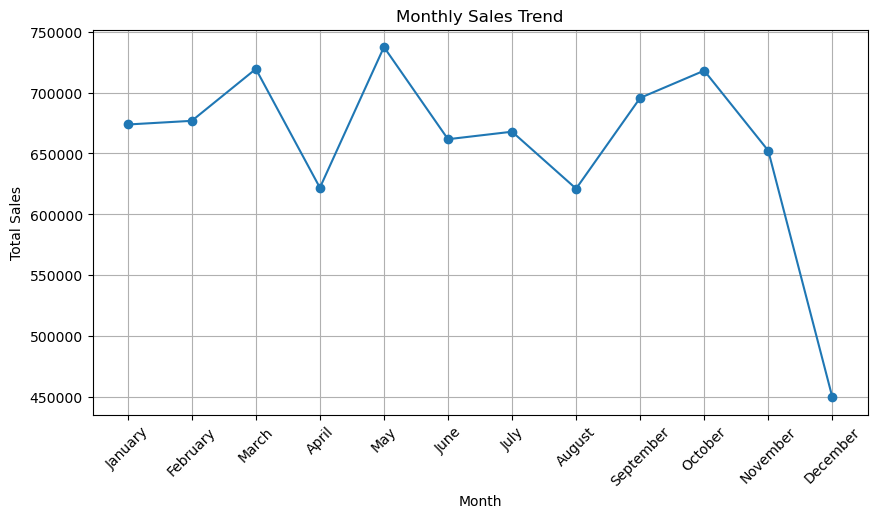

In [12]:
# Monthly Sales Trend

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales_name["Month Name"],
    monthly_sales_name["Total Amount"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [13]:
# Monthly Sales Trend Observation

highest_month = monthly_sales_name.loc[
    monthly_sales_name["Total Amount"].idxmax(), "Month Name"
]

highest_sales = monthly_sales_name["Total Amount"].max()

lowest_month = monthly_sales_name.loc[
    monthly_sales_name["Total Amount"].idxmin(), "Month Name"
]

lowest_sales = monthly_sales_name["Total Amount"].min()

print("Highest Sales Month:", highest_month)
print("Highest Sales:", highest_sales)

print("Lowest Sales Month:", lowest_month)
print("Lowest Sales:", lowest_sales)

Highest Sales Month: May
Highest Sales: 737348
Lowest Sales Month: December
Lowest Sales: 449846


In [14]:
# City-wise Sales Analysis

city_sales = (
    df_clean.groupby("City")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

print("City-wise Sales:")
print(city_sales)

print("\nTop Sales City:", city_sales.idxmax())
print("Sales:", city_sales.max())

City-wise Sales:
City
Nagpur        931937
Pune          839495
Mumbai        833066
Nashik        828805
Aurangabad    799108
Chennai       795217
Latur         761807
Delhi         725572
Bengaluru     684195
Hyderabad     655333
Unknown        40611
Name: Total Amount, dtype: int64

Top Sales City: Nagpur
Sales: 931937


In [15]:
# Repeat Customer Analysis

customer_orders = df_clean.groupby("Customer ID")["Order ID"].nunique()

repeat_customers = customer_orders[customer_orders > 1]

print("Total Unique Customers:", customer_orders.nunique())
print("Repeat Customers:", len(repeat_customers))

print("\nRepeat Customer Percentage:",
      round((len(repeat_customers) / len(customer_orders)) * 100, 2), "%")

Total Unique Customers: 8
Repeat Customers: 255

Repeat Customer Percentage: 88.54 %


In [16]:
customer_orders.nunique()

8

In [17]:
# Repeat Customer Analysis - Corrected

customer_orders = df_clean.groupby("Customer ID")["Order ID"].nunique()

total_customers = customer_orders.shape[0]

repeat_customers = customer_orders[customer_orders > 1]

print("Total Unique Customers:", total_customers)
print("Repeat Customers:", len(repeat_customers))

print(
    "Repeat Customer Percentage:",
    round((len(repeat_customers) / total_customers) * 100, 2),
    "%"
)

Total Unique Customers: 288
Repeat Customers: 255
Repeat Customer Percentage: 88.54 %


In [18]:
# Category-wise Revenue Analysis

category_revenue = (
    df_clean.groupby("Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Category-wise Revenue:")
print(category_revenue)

print("\nTop Revenue-Generating Category:", category_revenue.idxmax())
print("Revenue:", category_revenue.max())

Category-wise Revenue:
Category
Electronics       2492414
Home & Kitchen    1770380
Sports            1647387
Fashion           1116102
Beauty             806576
electronics         30244
Unknown             29407
BEAUTY               2636
Name: Total Amount, dtype: int64

Top Revenue-Generating Category: Electronics
Revenue: 2492414


In [19]:
# Category Revenue Contribution

total_revenue = df_clean["Total Amount"].sum()

category_revenue_percentage = (
    category_revenue / total_revenue * 100
).round(2)

print("Category Revenue Contribution (%):")
print(category_revenue_percentage)

Category Revenue Contribution (%):
Category
Electronics       31.57
Home & Kitchen    22.42
Sports            20.87
Fashion           14.14
Beauty            10.22
electronics        0.38
Unknown            0.37
BEAUTY             0.03
Name: Total Amount, dtype: float64


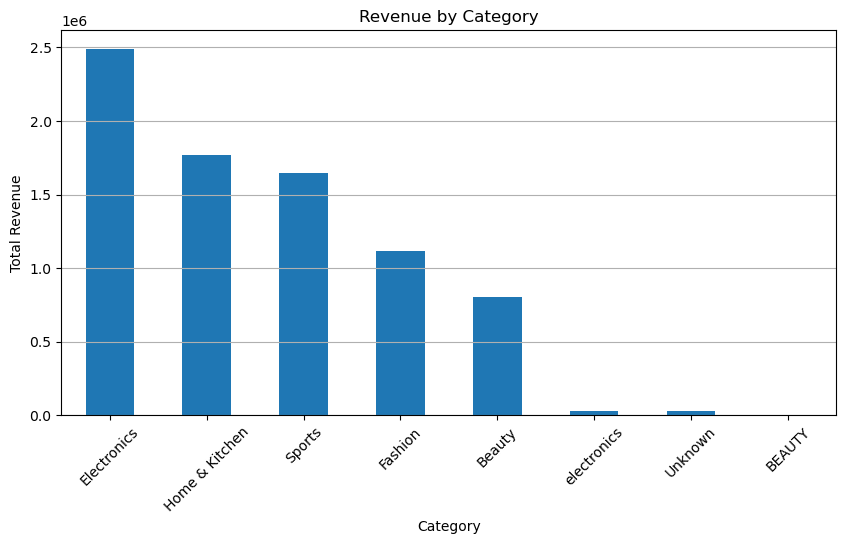

In [20]:
# Category-wise Revenue Bar Chart

plt.figure(figsize=(10, 5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [1]:
# Standardize Category names

df_clean["Category"] = df_clean["Category"].str.strip().str.title()

# Check categories
print(df_clean["Category"].value_counts())

NameError: name 'df_clean' is not defined

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df_clean = pd.read_csv(r"C:\Users\HP\Desktop\ecommerce_cleaned.csv")

print("Cleaned dataset loaded successfully!")
print("Rows:", len(df_clean))

Cleaned dataset loaded successfully!
Rows: 992


In [3]:
# Standardize Category names

df_clean["Category"] = df_clean["Category"].str.strip().str.title()

print(df_clean["Category"].value_counts())

Category
Sports            215
Fashion           206
Electronics       193
Beauty            191
Home & Kitchen    183
Unknown             4
Name: count, dtype: int64


In [4]:
category_revenue = (
    df_clean.groupby("Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Category-wise Revenue:")
print(category_revenue)

Category-wise Revenue:
Category
Electronics       2522658
Home & Kitchen    1770380
Sports            1647387
Fashion           1116102
Beauty             809212
Unknown             29407
Name: Total Amount, dtype: int64


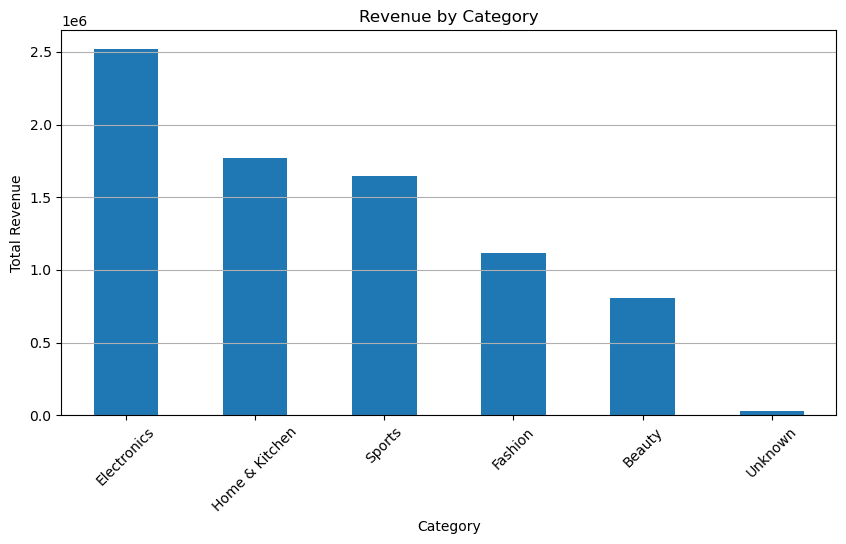

In [5]:
plt.figure(figsize=(10, 5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [6]:
# Monthly Sales Line Chart

monthly_sales = (
    df_clean.groupby("Month")["Total Amount"]
    .sum()
    .sort_index()
)

# Month names
monthly_sales_name = monthly_sales.reset_index()

monthly_sales_name["Month Name"] = pd.to_datetime(
    monthly_sales_name["Month"],
    format="%m"
).dt.strftime("%B")

print("Monthly Sales:")
print(monthly_sales_name)

KeyError: 'Month'

In [7]:
# Create Month column

df_clean["Month"] = df_clean["Order Date"].dt.month

print(df_clean[["Order Date", "Month"]].head())

AttributeError: Can only use .dt accessor with datetimelike values

In [8]:
# Create Month column

df_clean["Month"] = df_clean["Order Date"].dt.month

# Monthly Sales

monthly_sales = (
    df_clean.groupby("Month")["Total Amount"]
    .sum()
    .sort_index()
)

# Month names

month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

monthly_sales_name = monthly_sales.reset_index()

monthly_sales_name["Month Name"] = monthly_sales_name["Month"].map(month_names)

print("Monthly Sales:")
print(monthly_sales_name)

AttributeError: Can only use .dt accessor with datetimelike values

In [9]:
df_clean["Month"] = df_clean["Order Date"].dt.month

AttributeError: Can only use .dt accessor with datetimelike values

In [10]:


# Convert Order Date to datetime

df_clean["Order Date"] = pd.to_datetime(
    df_clean["Order Date"],
    errors="coerce"
)

print(df_clean["Order Date"].dtype)

datetime64[ns]


In [11]:
# Create Month column

df_clean["Month"] = df_clean["Order Date"].dt.month

print(df_clean[["Order Date", "Month"]].head())

  Order Date  Month
0 2025-08-03      8
1 2025-11-10     11
2 2025-06-24      6
3 2025-03-30      3
4 2025-02-04      2


In [12]:
# Monthly Sales Analysis

monthly_sales = (
    df_clean.groupby("Month")["Total Amount"]
    .sum()
    .sort_index()
)

print("Monthly Sales:")
print(monthly_sales)

Monthly Sales:
Month
1     673730
2     676749
3     719382
4     621803
5     737348
6     661650
7     667811
8     621015
9     695575
10    717983
11    652254
12    449846
Name: Total Amount, dtype: int64


In [13]:
# Add Month Names

month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

monthly_sales_name = monthly_sales.reset_index()

monthly_sales_name["Month Name"] = monthly_sales_name["Month"].map(month_names)

print("Monthly Sales:")
print(monthly_sales_name)

Monthly Sales:
    Month  Total Amount Month Name
0       1        673730    January
1       2        676749   February
2       3        719382      March
3       4        621803      April
4       5        737348        May
5       6        661650       June
6       7        667811       July
7       8        621015     August
8       9        695575  September
9      10        717983    October
10     11        652254   November
11     12        449846   December


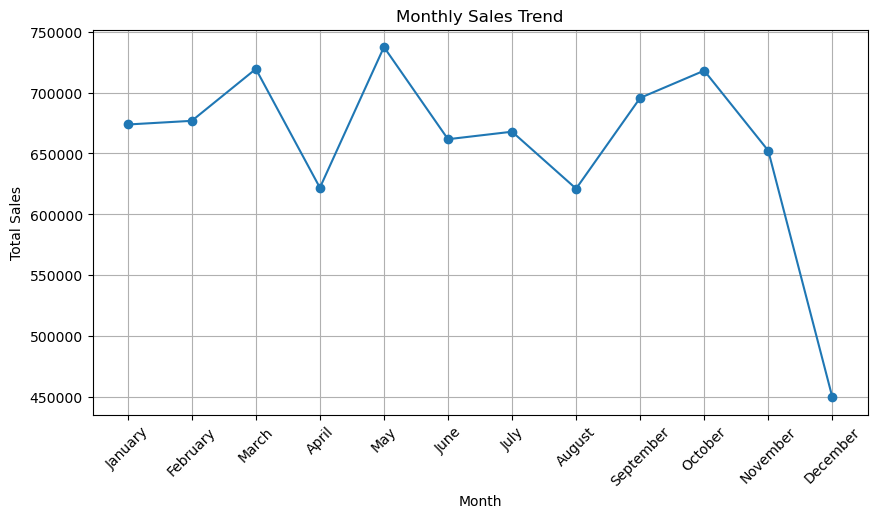

In [14]:
import matplotlib.pyplot as plt

# Monthly Sales Trend

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales_name["Month Name"],
    monthly_sales_name["Total Amount"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

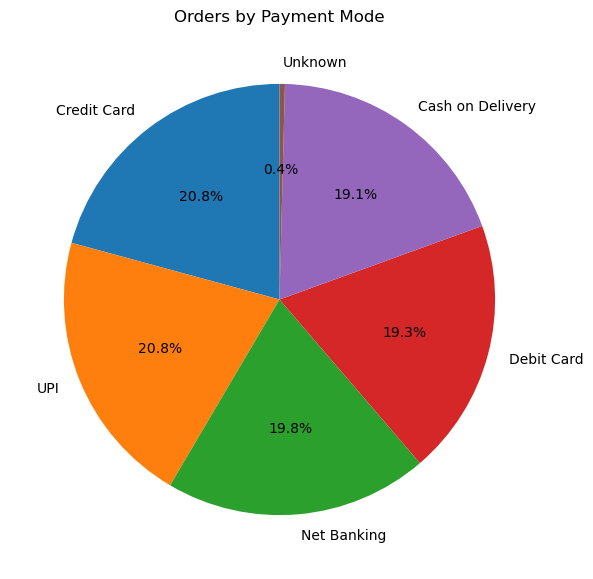

In [15]:
# Payment Mode Pie Chart

payment_counts = df_clean["Payment Mode"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Orders by Payment Mode")

plt.show()

NameError: name 'total_revenue' is not defined

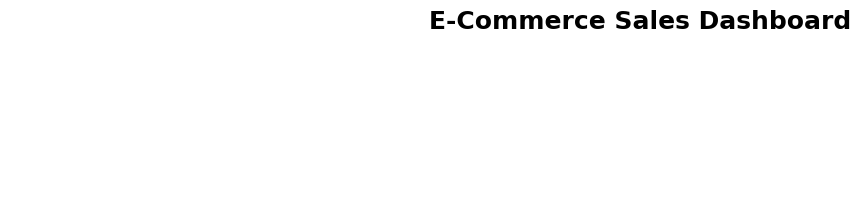

In [16]:
# Dashboard Mockup

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 9))

# Dashboard Title
fig.suptitle(
    "E-Commerce Sales Dashboard",
    fontsize=18,
    fontweight="bold"
)

# KPI 1
ax1 = fig.add_axes([0.05, 0.78, 0.20, 0.12])
ax1.axis("off")
ax1.text(
    0.5, 0.5,
    f"Total Revenue\n₹{total_revenue:,.0f}",
    ha="center",
    va="center",
    fontsize=14
)

# KPI 2
ax2 = fig.add_axes([0.28, 0.78, 0.20, 0.12])
ax2.axis("off")
ax2.text(
    0.5, 0.5,
    f"Total Orders\n{total_orders:,}",
    ha="center",
    va="center",
    fontsize=14
)

# KPI 3
ax3 = fig.add_axes([0.51, 0.78, 0.20, 0.12])
ax3.axis("off")
ax3.text(
    0.5, 0.5,
    f"Average Order Value\n₹{average_order_value:,.2f}",
    ha="center",
    va="center",
    fontsize=14
)

# KPI 4
ax4 = fig.add_axes([0.74, 0.78, 0.20, 0.12])
ax4.axis("off")
ax4.text(
    0.5, 0.5,
    f"Total Units Sold\n{total_units_sold:,}",
    ha="center",
    va="center",
    fontsize=14
)

# Monthly Sales
ax5 = fig.add_axes([0.08, 0.40, 0.40, 0.30])

ax5.plot(
    monthly_sales_name["Month Name"],
    monthly_sales_name["Total Amount"],
    marker="o"
)

ax5.set_title("Monthly Sales Trend")
ax5.set_xlabel("Month")
ax5.set_ylabel("Revenue")
ax5.tick_params(axis="x", rotation=45)
ax5.grid(True)

# Category Revenue
ax6 = fig.add_axes([0.55, 0.40, 0.38, 0.30])

category_revenue.plot(
    kind="bar",
    ax=ax6
)

ax6.set_title("Revenue by Category")
ax6.set_xlabel("Category")
ax6.set_ylabel("Revenue")
ax6.tick_params(axis="x", rotation=45)
ax6.grid(axis="y")

plt.show()

In [17]:
# Recalculate KPI values

total_revenue = df_clean["Total Amount"].sum()

total_orders = df_clean["Order ID"].nunique()

average_order_value = total_revenue / total_orders

total_units_sold = df_clean["Quantity"].sum()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))
print("Total Units Sold:", total_units_sold)

Total Revenue: 7895146
Total Orders: 991
Average Order Value: 7966.85
Total Units Sold: 2969


In [18]:
print(monthly_sales_name.head())
print(category_revenue)

   Month  Total Amount Month Name
0      1        673730    January
1      2        676749   February
2      3        719382      March
3      4        621803      April
4      5        737348        May
Category
Electronics       2522658
Home & Kitchen    1770380
Sports            1647387
Fashion           1116102
Beauty             809212
Unknown             29407
Name: Total Amount, dtype: int64


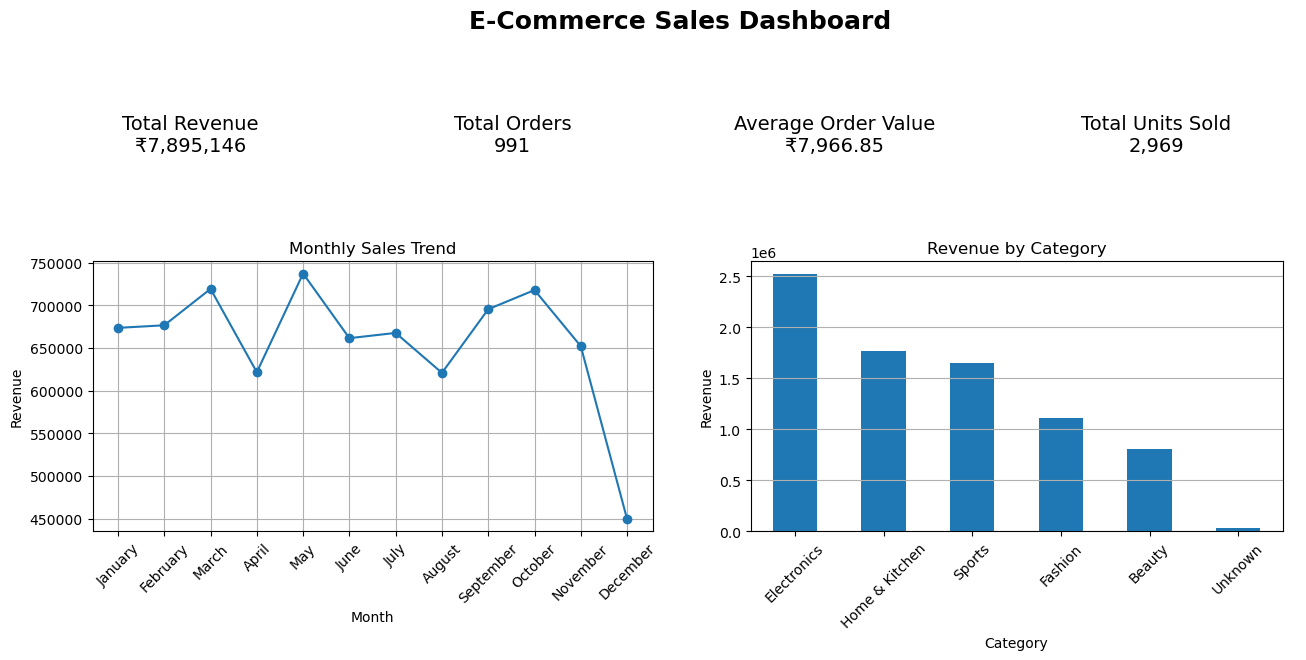

In [19]:
# E-Commerce Sales Dashboard

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 9))

fig.suptitle(
    "E-Commerce Sales Dashboard",
    fontsize=18,
    fontweight="bold"
)

# KPI 1 - Total Revenue
ax1 = fig.add_axes([0.05, 0.78, 0.20, 0.12])
ax1.axis("off")
ax1.text(
    0.5, 0.5,
    f"Total Revenue\n₹{total_revenue:,.0f}",
    ha="center",
    va="center",
    fontsize=14
)

# KPI 2 - Total Orders
ax2 = fig.add_axes([0.28, 0.78, 0.20, 0.12])
ax2.axis("off")
ax2.text(
    0.5, 0.5,
    f"Total Orders\n{total_orders:,}",
    ha="center",
    va="center",
    fontsize=14
)

# KPI 3 - Average Order Value
ax3 = fig.add_axes([0.51, 0.78, 0.20, 0.12])
ax3.axis("off")
ax3.text(
    0.5, 0.5,
    f"Average Order Value\n₹{average_order_value:,.2f}",
    ha="center",
    va="center",
    fontsize=14
)

# KPI 4 - Total Units Sold
ax4 = fig.add_axes([0.74, 0.78, 0.20, 0.12])
ax4.axis("off")
ax4.text(
    0.5, 0.5,
    f"Total Units Sold\n{total_units_sold:,}",
    ha="center",
    va="center",
    fontsize=14
)

# Monthly Sales Trend
ax5 = fig.add_axes([0.08, 0.40, 0.40, 0.30])

ax5.plot(
    monthly_sales_name["Month Name"],
    monthly_sales_name["Total Amount"],
    marker="o"
)

ax5.set_title("Monthly Sales Trend")
ax5.set_xlabel("Month")
ax5.set_ylabel("Revenue")
ax5.tick_params(axis="x", rotation=45)
ax5.grid(True)

# Revenue by Category
ax6 = fig.add_axes([0.55, 0.40, 0.38, 0.30])

category_revenue.plot(
    kind="bar",
    ax=ax6
)

ax6.set_title("Revenue by Category")
ax6.set_xlabel("Category")
ax6.set_ylabel("Revenue")
ax6.tick_params(axis="x", rotation=45)
ax6.grid(axis="y")

plt.show()

In [20]:
# Check dataset columns
print(df.columns.tolist())

NameError: name 'df' is not defined

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. City-wise Sales Analysis
print("--- City-wise Sales ---")
city_sales = df.groupby('City')['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False)
print(city_sales.head(10))

# 2. Payment Mode Analysis
print("\n--- Payment Mode Analysis ---")
payment_counts = df['Payment_Mode'].value_counts()
print(payment_counts)

# 3. Delivery Status Analysis
print("\n--- Delivery Status Analysis ---")
delivery_status = df['Delivery_Status'].value_counts(normalize=True) * 100
print(delivery_status)

# 4. Customer Analysis (Top Customers)
print("\n--- Top Customers ---")
top_customers = df.groupby('Customer_ID')['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False)
print(top_customers.head(10))

--- City-wise Sales ---


NameError: name 'df' is not defined

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df_clean = pd.read_csv(r"C:\Users\HP\Desktop\ecommerce_cleaned.csv")

print("Cleaned dataset loaded successfully!")
print("Rows:", len(df_clean))

Cleaned dataset loaded successfully!
Rows: 992


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. City-wise Sales Analysis
print("--- City-wise Sales ---")
city_sales = df.groupby('City')['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False)
print(city_sales.head(10))

# 2. Payment Mode Analysis
print("\n--- Payment Mode Analysis ---")
payment_counts = df['Payment_Mode'].value_counts()
print(payment_counts)

# 3. Delivery Status Analysis
print("\n--- Delivery Status Analysis ---")
delivery_status = df['Delivery_Status'].value_counts(normalize=True) * 100
print(delivery_status)

# 4. Customer Analysis (Top Customers)
print("\n--- Top Customers ---")
top_customers = df.groupby('Customer_ID')['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False)
print(top_customers.head(10))

--- City-wise Sales ---


NameError: name 'df' is not defined

In [4]:

import matplotlib.pyplot as plt


# 1. City-wise Sales Analysis
print("--- City-wise Sales ---")
city_sales = df_clean.groupby('City')['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False)
print(city_sales.head(10))

# 2. Payment Mode Analysis
print("\n--- Payment Mode Analysis ---")
payment_counts = df_clean['Payment_Mode'].value_counts()
print(payment_counts)

# 3. Delivery Status Analysis
print("\n--- Delivery Status Analysis ---")
delivery_status = df_clean['Delivery_Status'].value_counts(normalize=True) * 100
print(delivery_status)

# 4. Customer Analysis (Top Customers)
print("\n--- Top Customers ---")
top_customers = df_clean.groupby('Customer_ID')['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False)
print(top_customers.head(10))

--- City-wise Sales ---


KeyError: 'Column not found: Revenue'

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df_clean = pd.read_csv(r"C:\Users\HP\Desktop\ecommerce_cleaned.csv")

print("Cleaned dataset loaded successfully!")
print("Rows:", len(df_clean))

Cleaned dataset loaded successfully!
Rows: 992


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. City-wise Sales Analysis
print("--- City-wise Sales ---")
city_sales = df_clean.groupby('City')['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False)
print(city_sales.head(10))

# 2. Payment Mode Analysis
print("\n--- Payment Mode Analysis ---")
payment_counts = df_clean['Payment_Mode'].value_counts()
print(payment_counts)

# 3. Delivery Status Analysis
print("\n--- Delivery Status Analysis ---")
delivery_status = df_clean['Delivery_Status'].value_counts(normalize=True) * 100
print(delivery_status)

# 4. Customer Analysis (Top Customers)
print("\n--- Top Customers ---")
top_customers = df_clean.groupby('Customer_ID')['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False)
print(top_customers.head(10))

--- City-wise Sales ---


KeyError: 'Column not found: Revenue'

In [7]:
print(df_clean.columns)

Index(['Order ID', 'Customer ID', 'Product Name', 'Category', 'Quantity',
       'Unit Price', 'Total Amount', 'Order Date', 'Payment Mode',
       'Delivery Status', 'City'],
      dtype='object')


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. City-wise Sales Analysis
print("--- City-wise Sales ---")
city_sales = df_clean.groupby('City')['Total Amount'].sum().reset_index().sort_values(by='Total Amount', ascending=False)
print(city_sales.head(10))

# 2. Payment Mode Analysis
print("\n--- Payment Mode Analysis ---")
payment_counts = df_clean['Payment Mode'].value_counts()
print(payment_counts)

# 3. Delivery Status Analysis
print("\n--- Delivery Status Analysis ---")
delivery_status = df_clean['Delivery Status'].value_counts(normalize=True) * 100
print(delivery_status)

# 4. Customer Analysis (Top Customers)
print("\n--- Top Customers ---")
top_customers = df_clean.groupby('Customer ID')['Total Amount'].sum().reset_index().sort_values(by='Total Amount', ascending=False)
print(top_customers.head(10))

--- City-wise Sales ---
         City  Total Amount
7      Nagpur        931937
9        Pune        839495
6      Mumbai        833066
8      Nashik        828805
0  Aurangabad        799108
2     Chennai        795217
5       Latur        761807
3       Delhi        725572
1   Bengaluru        684195
4   Hyderabad        655333

--- Payment Mode Analysis ---
Payment Mode
Credit Card         206
UPI                 206
Net Banking         196
Debit Card          191
Cash on Delivery    189
Unknown               4
Name: count, dtype: int64

--- Delivery Status Analysis ---
Delivery Status
Delivered     72.379032
Shipped       12.802419
Processing     8.165323
Cancelled      6.653226
Name: proportion, dtype: float64

--- Top Customers ---
    Customer ID  Total Amount
65     CUST0069        108926
7      CUST0008         98961
44     CUST0048         94009
216    CUST0227         93292
121    CUST0127         79153
214    CUST0225         74655
271    CUST0284         70701
137    CUST0

C:\Users\HP\AppData\Local\Temp\ipykernel_33092\611636829.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='City', y='Total Amount', data=city_sales, palette='viridis')


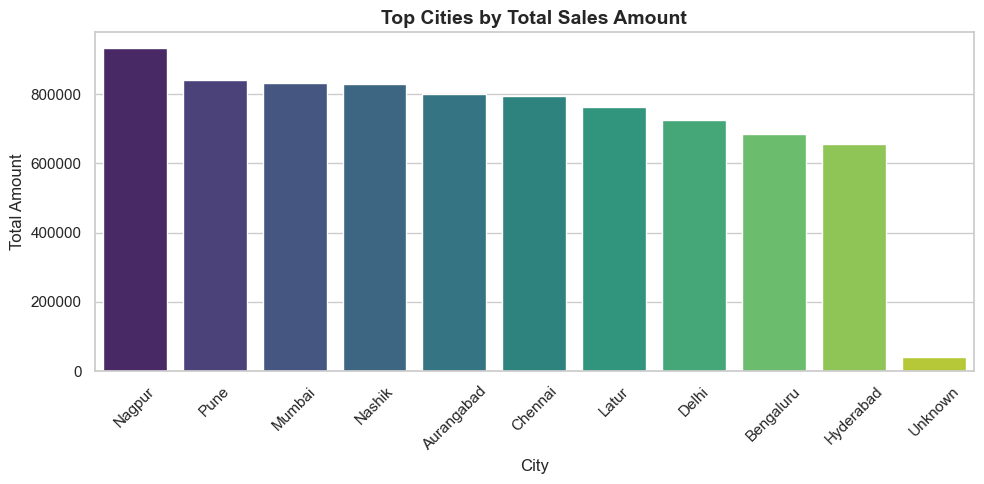

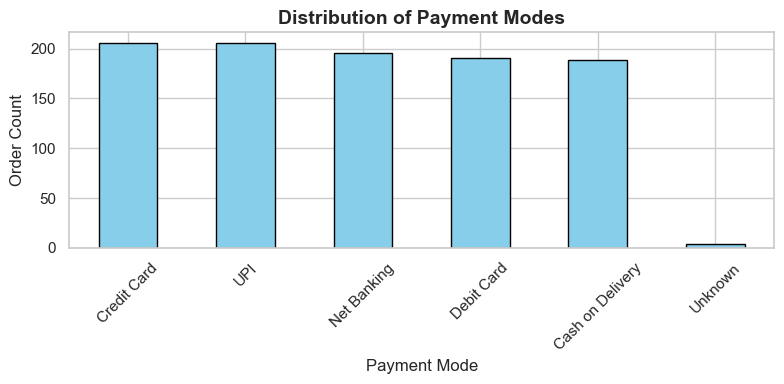

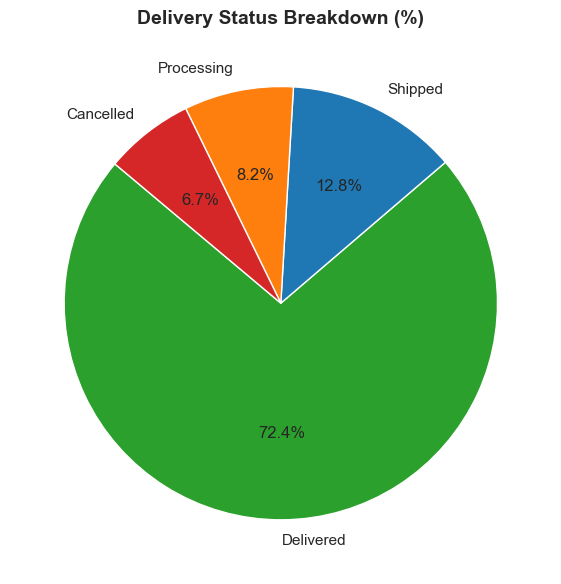

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the overall visual style
sns.set_theme(style="whitegrid")

# 1. City-wise Sales Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x='City', y='Total Amount', data=city_sales, palette='viridis')
plt.title('Top Cities by Total Sales Amount', fontsize=14, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Total Amount', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Payment Mode Distribution Bar Chart
plt.figure(figsize=(8, 4))
payment_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Payment Modes', fontsize=14, fontweight='bold')
plt.xlabel('Payment Mode', fontsize=12)
plt.ylabel('Order Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Delivery Status Percentage Pie Chart
plt.figure(figsize=(6, 6))
delivery_status.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'])
plt.title('Delivery Status Breakdown (%)', fontsize=14, fontweight='bold')
plt.ylabel('')  # Remove the y-label for clean look
plt.tight_layout()
plt.show()

--- Category-wise Sales ---
         Category  Total Amount
2     Electronics       2492414
4  Home & Kitchen       1770380
5          Sports       1647387
3         Fashion       1116102
1          Beauty        806576
7     electronics         30244
6         Unknown         29407
0          BEAUTY          2636

--- Monthly Sales Trend ---
   Month_Year  Total Amount
0     2025-01        673730
1     2025-02        676749
2     2025-03        719382
3     2025-04        621803
4     2025-05        737348
5     2025-06        661650
6     2025-07        667811
7     2025-08        621015
8     2025-09        695575
9     2025-10        717983
10    2025-11        652254
11    2025-12        449846


C:\Users\HP\AppData\Local\Temp\ipykernel_33092\2356671944.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Total Amount', data=category_sales, palette='magma')


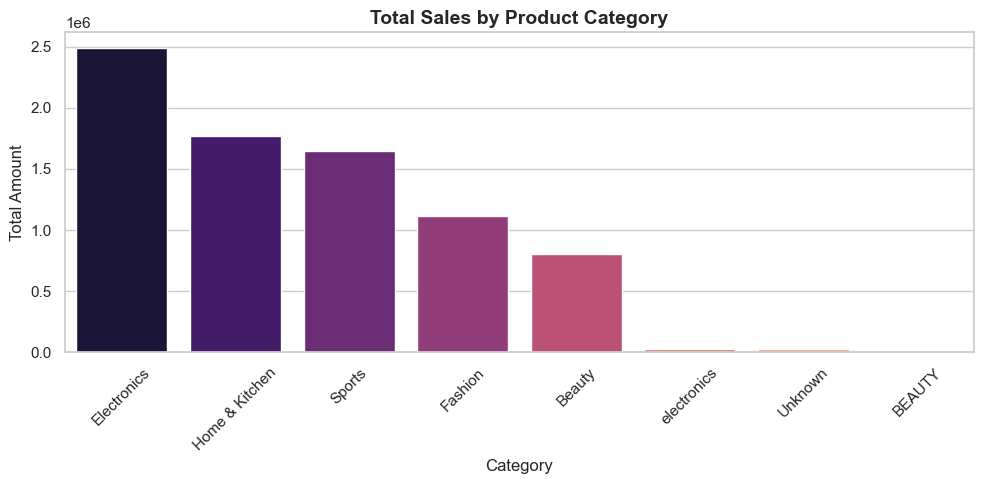

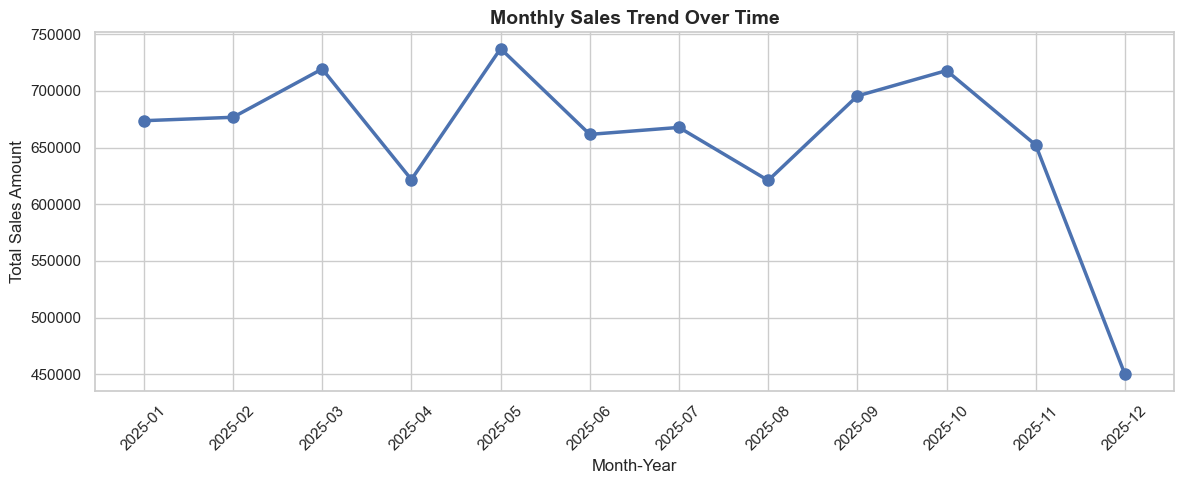

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure visual style is set
sns.set_theme(style="whitegrid")

# 1. Category-wise Sales Analysis
print("--- Category-wise Sales ---")
category_sales = df_clean.groupby('Category')['Total Amount'].sum().reset_index().sort_values(by='Total Amount', ascending=False)
print(category_sales)

# 2. Monthly Sales Trend Analysis
# Convert 'Order Date' to datetime format if not already done
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'])
df_clean['Month_Year'] = df_clean['Order Date'].dt.to_period('M')

print("\n--- Monthly Sales Trend ---")
monthly_sales = df_clean.groupby('Month_Year')['Total Amount'].sum().reset_index()
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].astype(str)
print(monthly_sales)

# --- VISUALIZATIONS ---

# Chart 1: Category-wise Sales Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x='Category', y='Total Amount', data=category_sales, palette='magma')
plt.title('Total Sales by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Amount', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 2: Monthly Sales Trend Line Chart
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Month_Year'], monthly_sales['Total Amount'], marker='o', color='b', linewidth=2.5, markersize=8)
plt.title('Monthly Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Sales Amount', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

--- Top 10 Products by Revenue ---
           Product Name  Total Amount
1     Bluetooth Speaker        594681
17          Smart Watch        500938
14           Power Bank        486586
21            USB Cable        462603
24  Wireless Headphones        456515
11        Mixer Grinder        437759
3           Cricket Bat        395351
4             Dumbbells        357820
2          Cookware Set        353723
23         Water Bottle        348846

--- Statistical Summary ---
         Quantity   Unit Price  Total Amount                     Order Date
count  992.000000   992.000000    992.000000                            992
mean     2.992944  2623.815524   7958.816532  2025-06-25 20:58:32.903226112
min      1.000000   156.000000    156.000000            2025-01-01 00:00:00
25%      2.000000  1262.000000   2720.000000            2025-03-26 00:00:00
50%      3.000000  2229.000000   5692.000000            2025-06-21 00:00:00
75%      4.000000  3641.750000  11111.250000            2025-0

C:\Users\HP\AppData\Local\Temp\ipykernel_33092\1078600898.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Amount', y='Product Name', data=top_products.head(10), palette='crest')


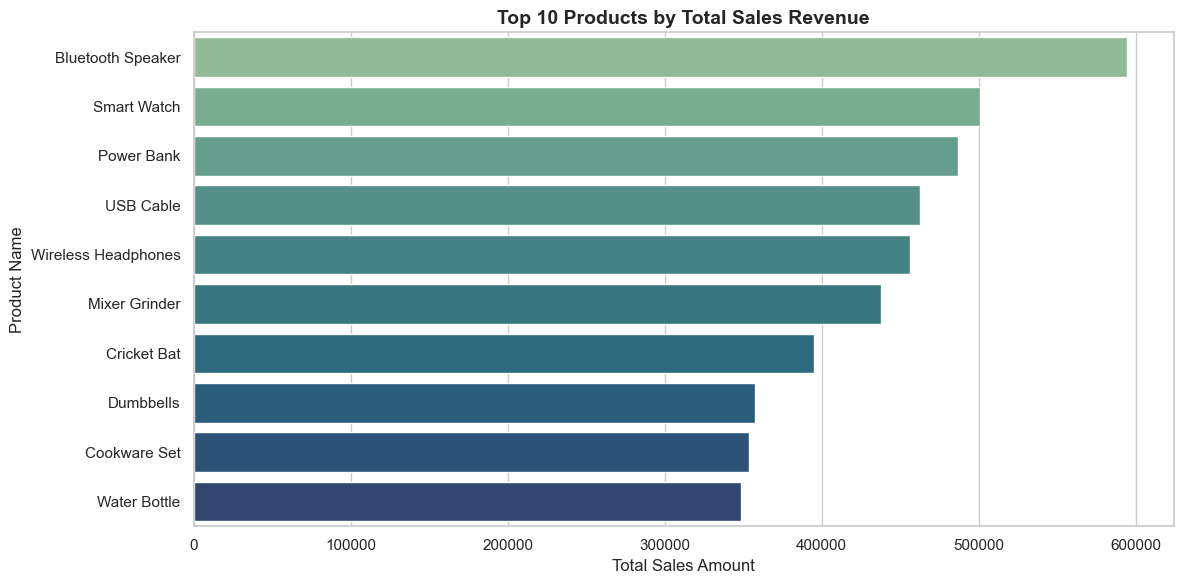

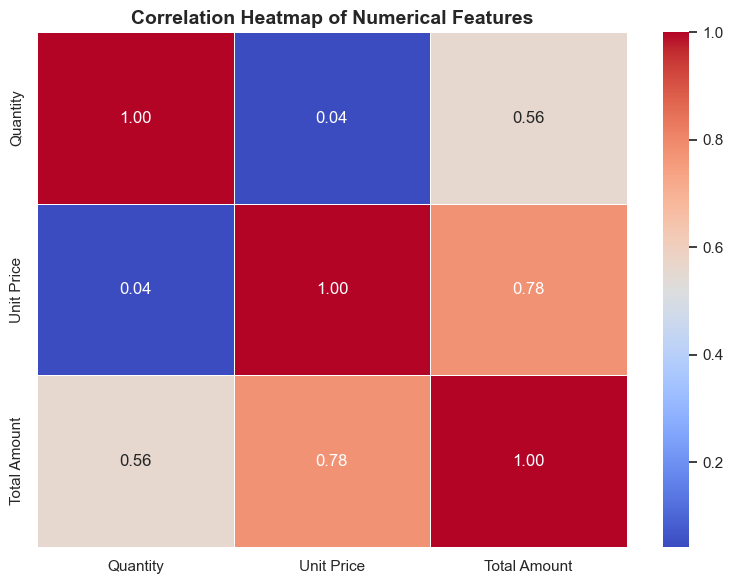

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure visual style is set
sns.set_theme(style="whitegrid")

# 1. Top 10 Products by Sales Revenue
print("--- Top 10 Products by Revenue ---")
top_products = df_clean.groupby('Product Name')['Total Amount'].sum().reset_index().sort_values(by='Total Amount', ascending=False)
print(top_products.head(10))

# 2. Statistical Summary
print("\n--- Statistical Summary ---")
print(df_clean.describe())

# --- VISUALIZATIONS ---

# Chart 1: Top 10 Products Horizontal Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x='Total Amount', y='Product Name', data=top_products.head(10), palette='crest')
plt.title('Top 10 Products by Total Sales Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales Amount', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()

# Chart 2: Correlation Heatmap for Numerical Columns
plt.figure(figsize=(8, 6))
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# 1. Export the full cleaned dataset
df_clean.to_csv(r"C:\Users\HP\Desktop\ecommerce_final_processed.csv", index=False)

# 2. Export Top Products summary table
top_products.head(10).to_csv(r"C:\Users\HP\Desktop\top_products_summary.csv", index=False)

# 3. Export Monthly Sales Trend table
monthly_sales.to_csv(r"C:\Users\HP\Desktop\monthly_sales_trend.csv", index=False)

print("All cleaned data and summary reports have been successfully exported to your Desktop!")

All cleaned data and summary reports have been successfully exported to your Desktop!
